In [51]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
scenario = 0 # 0 = A, 1 = B, 2 = C

## Question 2.1

In [53]:
def build_matrix(scenario):
    """
    Build the 76x76 transition matrix for the Smart Home Energy System.

    State encoding:  index = B*15 + W*3 + C   (0..74 = operational, 75 = failure)
      B in {0,1,2,3,4}  – battery level
      W in {0,1,2,3,4}  – weather  (0=Stormy … 4=Sunny)
      C in {0,1,2}      – consumption (0=Low … 2=High)

    Physics:
      B' = clip(B + W - C, 0, 4)   (deterministic given current state)

    Stochastic environment:
      Weather : P(stay)=0.6, P(±1)=0.2 each  (reflective boundaries)
      Consumption: P(stay)=0.7, P(±1)=0.15 each (reflective boundaries)
    """

    P = np.zeros((76, 76))

    # ── helper: build marginal transition distributions ─────────────────────
    def marginal(state, max_val, p_stay, p_step):
        """Return dict {next_state: probability} with reflective boundaries."""
        dist = {state: p_stay}
        for delta in (-1, +1):
            nb = state + delta
            if 0 <= nb <= max_val:
                dist[nb] = dist.get(nb, 0) + p_step
            else:                          # reflect probability back to boundary
                dist[state] = dist.get(state, 0) + p_step
        return dist

    # ── fill operational rows (0..74) ────────────────────────────────────────
    for i in range(75):
        B = i // 15
        W = (i % 15) // 3
        C = i % 3

        B_prime = int(np.clip(B + W - C, 0, 4))

        w_dist = marginal(W, 4, p_stay=0.6, p_step=0.2)
        c_dist = marginal(C, 2, p_stay=0.7, p_step=0.15)

        for w_next, pw in w_dist.items():
            for c_next, pc in c_dist.items():
                j = B_prime * 15 + w_next * 3 + c_next
                P[i, j] += pw * pc

    # ── failure state is a sink ──────────────────────────────────────────────
    P[75, 75] = 1.0

    # ── scenario modifications ───────────────────────────────────────────────
    if scenario == 1:  # Scenario B – Brittle-Bottom
        # If P(row → 0) > 10 %, redirect exactly 10 % to failure
        for row in range(75):
            if P[row, 0] > 0.10:
                P[row, 75] += 0.10
                P[row, 0]  -= 0.10

    elif scenario == 2:  # Scenario C – Extreme-Stress
        # For every next operational state where B'=0 or B'=4 and P>5 %,
        # redirect exactly 5 % to failure
        for row in range(75):
            for j in range(75):
                b_prime = j // 15
                if (b_prime == 0 or b_prime == 4) and P[row, j] > 0.05:
                    P[row, 75] += 0.05
                    P[row, j]  -= 0.05

    return P

# np.set_printoptions(threshold=np.inf, linewidth=200, precision=4, suppress=True)

M = build_matrix(scenario)
print("Shape     :", M.shape)
print(M)


Shape     : (76, 76)
[[0.68 0.12 0.   ... 0.   0.   0.  ]
 [0.12 0.56 0.12 ... 0.   0.   0.  ]
 [0.   0.12 0.68 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.56 0.12 0.  ]
 [0.   0.   0.   ... 0.12 0.68 0.  ]
 [0.   0.   0.   ... 0.   0.   1.  ]]


## Question 2.2

In [54]:
def generate_trajectories(P, s0, Nr, Ns):
    """
    Generates Nr trajectories of Ns steps starting in an initial state s0.
    """
    trajectories = np.zeros((Nr, Ns + 1), dtype=int)
    trajectories[:, 0] = s0
    
    # Generate the paths
    for t in range(1, Ns + 1):
        for r in range(Nr):
            current_state = trajectories[r, t-1]
            
            probs = P[current_state] / np.sum(P[current_state])
            
            next_state = np.random.choice(76, p=probs)
            trajectories[r, t] = next_state
            
    return trajectories

def compare_probabilities(P, s0, Nr_list=[100, 1000, 4000], Ns=40):
    """
    Computes and plots both theoretical and empirical probabilities of failure.
    Plots multiple empirical curves for different numbers of runs.
    """
    # Compute theoretical probability
    theoretical_prob = np.zeros(Ns + 1)
    
    mu = np.zeros(76)
    mu[s0] = 1.0
    
    theoretical_prob[0] = mu[75]
    
    for t in range(1, Ns + 1):
        mu = np.dot(mu, P)
        theoretical_prob[t] = mu[75]
    
    time_steps = np.arange(Ns + 1)
    
    # Create plot
    plt.figure(figsize=(10, 6))
    
    # Plot theoretical
    plt.plot(time_steps, theoretical_prob, label='Theoretical $\mu_t[75]$', 
             linewidth=2, color='blue')
    
    # Define colors for different Nr values
    colors = ['orange', 'green', 'red']
    
    # Plot empirical for each Nr value
    for idx, Nr in enumerate(Nr_list):
        print(f"Simulating {Nr} trajectories...")
        trajectories = generate_trajectories(P, s0, Nr, Ns)
        
        # trajectories are in state 75 at each time step, divided by total runs
        empirical_prob = np.sum(trajectories == 75, axis=0) / Nr
        
        plt.plot(time_steps, empirical_prob, label=f'Empirical (Nr={Nr})', 
                 linestyle='--', color=colors[idx % len(colors)])
    
    plt.title('Probability of System Failure Over Time')
    plt.xlabel('Time Step $t$')
    plt.ylabel('Probability of Failure (State 75)')
    plt.legend()
    plt.grid(True)
    plt.show()


<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_81871/2112625221.py:43: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(time_steps, theoretical_prob, label='Theoretical $\mu_t[75]$',


Simulating 100 trajectories...
Simulating 1000 trajectories...
Simulating 4000 trajectories...


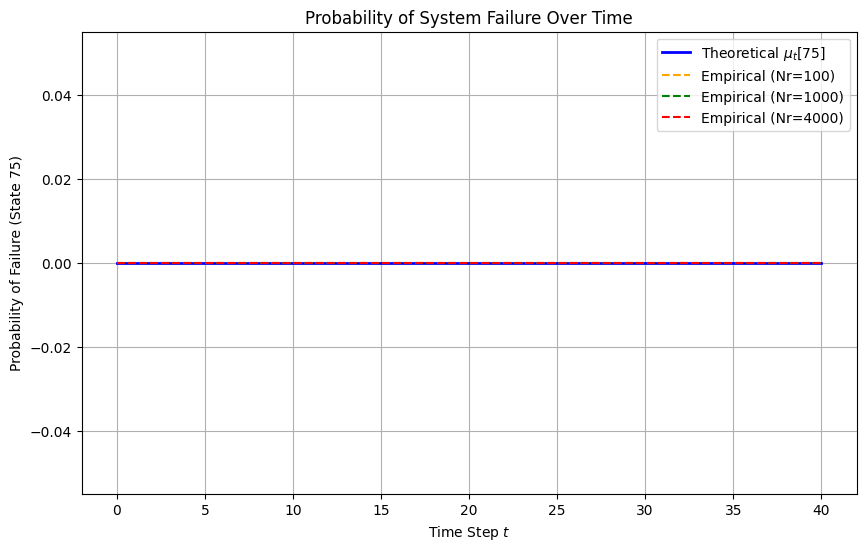

In [55]:
P_scenario_C = build_matrix(scenario=scenario)

compare_probabilities(P_scenario_C, s0=37, Nr_list=[100, 1000, 4000], Ns=40)


## Question 2.3

In [56]:

# ── Initial state s0 = (B=2, W=2, C=1) ─────────────────────────────────────
s0 = 2 * 15 + 2 * 3 + 1   # = 37

def distribution_after_n_steps(P, s0, N):
    """
    Compute the distribution µ_N after N steps via power iteration.

    µ_0 is a point mass on s0.
    µ_{n+1} = µ_n @ P   (row vector × transition matrix)

    Parameters
    ----------
    P  : (76, 76) row-stochastic transition matrix
    s0 : int, index of the initial state
    N  : int, number of steps

    Returns
    -------
    mu : (76,) array, probability distribution over states after N steps
    """
    mu = np.zeros(P.shape[0])
    mu[s0] = 1.0
    for _ in range(N):
        mu = mu @ P
    return mu


def stationary_distribution(P, tol=1e-10):
    """
    Compute the stationary distribution π via eigen-decomposition.

    π satisfies  π @ P = π  (left eigenvector for eigenvalue 1).
    We find it as the left eigenvector of P corresponding to eigenvalue 1,
    which equals the right eigenvector of P^T for eigenvalue 1.

    If the chain has an absorbing state (e.g. failure state 75) the unique
    stationary distribution concentrates entirely on that absorbing class.

    Parameters
    ----------
    P   : (76, 76) row-stochastic transition matrix
    tol : tolerance for identifying eigenvalue = 1

    Returns
    -------
    pi : (76,) array, stationary distribution (normalised, non-negative),
         or None if no eigenvalue-1 eigenvector with non-negative entries
         is found.
    """
    eigenvalues, eigenvectors = np.linalg.eig(P.T)   # right eigs of P^T = left eigs of P

    # find all eigenvalues close to 1
    candidates = []
    for idx, ev in enumerate(eigenvalues):
        if np.isclose(ev.real, 1.0, atol=tol) and np.isclose(ev.imag, 0.0, atol=tol):
            vec = eigenvectors[:, idx].real
            if np.all(vec >= -tol):               # must be non-negative
                vec = np.maximum(vec, 0)
                vec /= vec.sum()                  # normalise to a probability vector
                candidates.append(vec)

    if not candidates:
        print("No stationary distribution found.")
        return None

    if len(candidates) > 1:
        print(f"Multiple ({len(candidates)}) stationary distributions found "
              "(chain has several closed communicating classes).")

    return candidates[0] if len(candidates) == 1 else candidates


# ── Demo ─────────────────────────────────────────────────────────────────────
for N in [1, 10, 100]:
    mu = distribution_after_n_steps(M, s0, N)
    print(f"µ_{N:>3d}  sum={mu.sum():.6f}  "
          f"top-3 states: {np.argsort(mu)[-3:][::-1].tolist()}  "
          f"P(failure)={mu[75]:.6f}")

pi = stationary_distribution(M)
if pi is not None:
    pi_list = pi if isinstance(pi, list) else [pi]
    for k, p in enumerate(pi_list):
        label = f"Stationary π[{k}]" if len(pi_list) > 1 else "Stationary π"
        print(f"\n{label}  sum={p.sum():.6f}  "
              f"top-3 states: {np.argsort(p)[-3:][::-1].tolist()}  "
              f"π(failure)={p[75]:.6f}")


µ_  1  sum=1.000000  top-3 states: [52, 55, 49]  P(failure)=0.000000
µ_ 10  sum=1.000000  top-3 states: [66, 69, 70]  P(failure)=0.000000
µ_100  sum=1.000000  top-3 states: [72, 73, 69]  P(failure)=0.000000
Multiple (2) stationary distributions found (chain has several closed communicating classes).

Stationary π[0]  sum=1.000000  top-3 states: [72, 73, 69]  π(failure)=0.000000

Stationary π[1]  sum=1.000000  top-3 states: [75, 74, 73]  π(failure)=1.000000


## Question 2.4

In [57]:
def expected_hitting_time(P, absorbing_state=75):
    """
    Compute the expected hitting time to the absorbing state from each transient state.
    
    For an absorbing Markov chain, we partition the transition matrix as:
        P = [Q  R]
            [0  I]
    where Q is transitions between transient states,
          R is transitions from transient to absorbing states.
    
    The expected hitting time vector h satisfies:
        h = 1 + Q @ h
    which gives:
        h = (I - Q)^(-1) @ 1
    """
    n_states = P.shape[0]
    transient_states = [i for i in range(n_states) if i != absorbing_state]
    
    # Extract Q submatrix (transient to transient transitions)
    Q = P[np.ix_(transient_states, transient_states)]
    
    # Solve (I - Q) h = 1
    I = np.eye(len(transient_states))
    ones = np.ones(len(transient_states))
    
    hitting_times = np.linalg.solve(I - Q, ones)
    
    return hitting_times


# Compute for Scenario C (scenario=2)
P_scenario_C = build_matrix(scenario=2)

hitting_times = expected_hitting_time(P_scenario_C, absorbing_state=75)

# Show expected time from initial state s0 = 37
s0 = 37
print(f"Expected time to failure from state {s0}: {hitting_times[s0]:.4f} steps")


Expected time to failure from state 37: 7.1791 steps


## Question 2.5

<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_81871/998062393.py:70: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Probability of Failure $\mu_t[75]$')


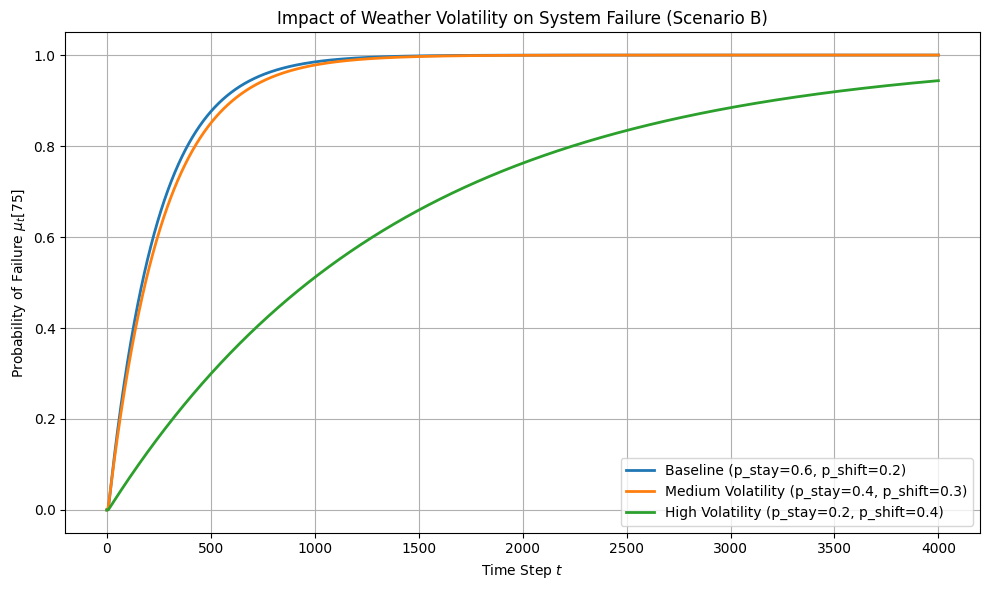

In [58]:
import numpy as np
import matplotlib.pyplot as plt

def get_volatile_weather_prob(w, w_next, p_stay, p_shift):
    """Calculates weather transition with adjustable volatility."""
    if w_next == w:
        return p_stay + p_shift if (w == 0 or w == 4) else p_stay
    elif abs(w - w_next) == 1:
        return p_shift
    return 0.0

def build_custom_matrix(p_stay, p_shift):
    P = np.zeros((76, 76))
    for b in range(5):
        for w in range(5):
            for c in range(3):
                current_idx = (b * 15) + (w * 3) + c
                b_next = np.clip(b + w - c, 0, 4)
                
                for w_next in range(5):
                    for c_next in range(3):
                        next_idx = (b_next * 15) + (w_next * 3) + c_next
                        
                        p_w = get_volatile_weather_prob(w, w_next, p_stay, p_shift)
                        
                        # Standard consumption (0.7 stay, 0.15 shift)
                        p_c_stay = 0.85 if (c == 0 or c == 2) else 0.7
                        p_c = p_c_stay if c == c_next else (0.15 if abs(c - c_next) == 1 else 0.0)
                        
                        P[current_idx, next_idx] += p_w * p_c

    P[75, 75] = 1.0
    
    for i in range(75):
        if P[i, 0] > 0.10:
            P[i, 0] -= 0.10
            P[i, 75] += 0.10
            
    return P

def plot_volatility_impact():
    s0 = 37
    Ns = 4000 
    
    cases = [
        (0.6, 0.2, "Baseline (p_stay=0.6, p_shift=0.2)"),
        (0.4, 0.3, "Medium Volatility (p_stay=0.4, p_shift=0.3)"),
        (0.2, 0.4, "High Volatility (p_stay=0.2, p_shift=0.4)")
    ]
    
    plt.figure(figsize=(10, 6))
    
    for p_stay, p_shift, label in cases:
        P = build_custom_matrix(p_stay, p_shift)
        
        # Initialize state distribution
        mu = np.zeros(76)
        mu[s0] = 1.0
        
        # Track failure probability over time using exact matrix multiplication
        failure_probs = [mu[75]]
        for _ in range(Ns):
            mu = np.dot(mu, P)
            failure_probs.append(mu[75])
            
        plt.plot(range(Ns + 1), failure_probs, label=label, linewidth=2)
    
    plt.title('Impact of Weather Volatility on System Failure (Scenario B)')
    plt.xlabel('Time Step $t$')
    plt.ylabel('Probability of Failure $\mu_t[75]$')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the function
plot_volatility_impact()

## Question 2.6

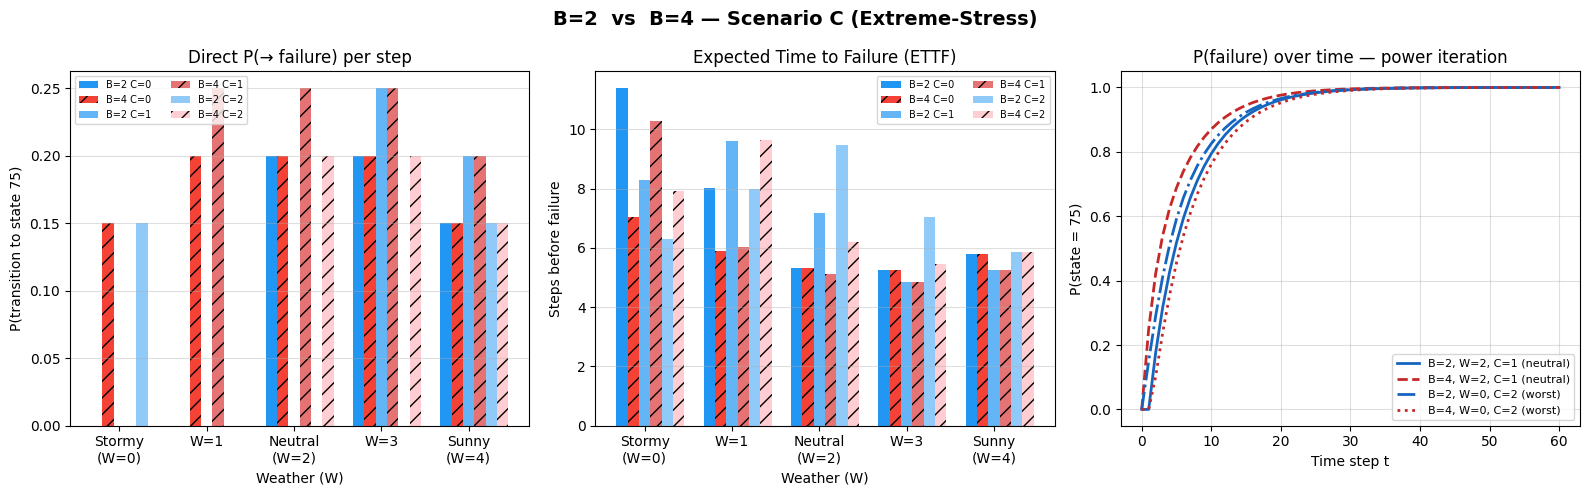

ETTF summary  (W=2, C=1  —  neutral conditions)
  B=2 : 7.18 steps
  B=4 : 5.13 steps

Average ETTF across all (W,C):
  B=2 : 7.17 steps
  B=4 : 6.40 steps


In [59]:
# ── Setup ────────────────────────────────────────────────────────────────────
P_C = build_matrix(scenario=2)

Q     = P_C[:75, :75]
ettf  = np.linalg.inv(np.eye(75) - Q).sum(axis=1)   # ETTF per state

W_labels = ['Stormy\n(W=0)', 'W=1', 'Neutral\n(W=2)', 'W=3', 'Sunny\n(W=4)']
x = np.arange(5)
width = 0.13

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('B=2  vs  B=4 — Scenario C (Extreme-Stress)', fontsize=14, fontweight='bold')

colors_B2 = ['#2196F3', '#64B5F6', '#90CAF9']   # blues for B=2
colors_B4 = ['#F44336', '#E57373', '#FFCDD2']   # reds  for B=4

# ── Chart 1: direct P(→ failure) per (W, C) ─────────────────────────────────
ax = axes[0]
for ci, c in enumerate(range(3)):
    p_B2 = [P_C[2*15 + w*3 + c, 75] for w in range(5)]
    p_B4 = [P_C[4*15 + w*3 + c, 75] for w in range(5)]
    offset = (ci - 1) * 2 * width
    ax.bar(x + offset,         p_B2, width, label=f'B=2 C={c}', color=colors_B2[ci])
    ax.bar(x + offset + width, p_B4, width, label=f'B=4 C={c}', color=colors_B4[ci], hatch='//')
ax.set_title('Direct P(→ failure) per step')
ax.set_xlabel('Weather (W)')
ax.set_ylabel('P(transition to state 75)')
ax.set_xticks(x); ax.set_xticklabels(W_labels)
ax.legend(fontsize=7, ncol=2); ax.grid(axis='y', alpha=0.4)

# ── Chart 2: ETTF per (W, C) ─────────────────────────────────────────────────
ax = axes[1]
for ci, c in enumerate(range(3)):
    e_B2 = [ettf[2*15 + w*3 + c] for w in range(5)]
    e_B4 = [ettf[4*15 + w*3 + c] for w in range(5)]
    offset = (ci - 1) * 2 * width
    ax.bar(x + offset,         e_B2, width, label=f'B=2 C={c}', color=colors_B2[ci])
    ax.bar(x + offset + width, e_B4, width, label=f'B=4 C={c}', color=colors_B4[ci], hatch='//')
ax.set_title('Expected Time to Failure (ETTF)')
ax.set_xlabel('Weather (W)')
ax.set_ylabel('Steps before failure')
ax.set_xticks(x); ax.set_xticklabels(W_labels)
ax.legend(fontsize=7, ncol=2); ax.grid(axis='y', alpha=0.4)

# ── Chart 3: P(in failure) over time — power iteration ───────────────────────
ax = axes[2]
Ns = 60
time_steps = np.arange(Ns + 1)

start_states = {
    'B=2, W=2, C=1 (neutral)': 2*15 + 2*3 + 1,
    'B=4, W=2, C=1 (neutral)': 4*15 + 2*3 + 1,
    'B=2, W=0, C=2 (worst)':   2*15 + 0*3 + 2,
    'B=4, W=0, C=2 (worst)':   4*15 + 0*3 + 2,
}
line_styles = ['-', '--', '-.', ':']
line_colors = ['#1565C0', '#C62828', '#1565C0', '#C62828']

for (label, s), ls, col in zip(start_states.items(), line_styles, line_colors):
    mu = np.zeros(76); mu[s] = 1.0
    p_fail = [mu[75]]
    for _ in range(Ns):
        mu = mu @ P_C
        p_fail.append(mu[75])
    ax.plot(time_steps, p_fail, ls=ls, color=col, linewidth=2, label=label)

ax.set_title('P(failure) over time — power iteration')
ax.set_xlabel('Time step t')
ax.set_ylabel('P(state = 75)')
ax.legend(fontsize=8); ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# ── Print ETTF summary ────────────────────────────────────────────────────────
print("ETTF summary  (W=2, C=1  —  neutral conditions)")
print(f"  B=2 : {ettf[2*15 + 2*3 + 1]:.2f} steps")
print(f"  B=4 : {ettf[4*15 + 2*3 + 1]:.2f} steps")
print(f"\nAverage ETTF across all (W,C):")
print(f"  B=2 : {np.mean([ettf[2*15 + w*3 + c] for w in range(5) for c in range(3)]):.2f} steps")
print(f"  B=4 : {np.mean([ettf[4*15 + w*3 + c] for w in range(5) for c in range(3)]):.2f} steps")